# Disagreement Ensemble Correction Pipeline — Dataset 6

In [1]:
import shap
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
print('All imports successful.')

c:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


## Helper Functions

In [2]:
def print_metrics(y_true, y_pred, label=''):
    if label:
        print(f'\n{"="*12} {label} {"="*12}')
    print(f'  Accuracy : {accuracy_score(y_true, y_pred):.5f}')
    print(f'  F1       : {f1_score(y_true, y_pred):.5f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.5f}')
    print(f'  Recall   : {recall_score(y_true, y_pred):.5f}')


def print_comparison(y_true, y_orig, y_corr, label=''):
    if label:
        print(f'\n{"="*12} {label} {"="*12}')
    print(f"  {'Metric':<12} {'Baseline':>10} {'Corrected':>10} {'Delta':>10}")
    print(f"  {'-'*44}")
    for name, fn in [('Accuracy', accuracy_score), ('F1', f1_score),
                     ('Precision', precision_score), ('Recall', recall_score)]:
        o = fn(y_true, y_orig)
        c = fn(y_true, y_corr)
        d = c - o
        print(f"  {name:<12} {o:>10.5f} {c:>10.5f} {('+' if d>=0 else '')+f'{d:.5f}':>10}")


def flip_report(y_orig, y_corr, y_true, label=''):
    flipped = y_orig != y_corr
    n = flipped.sum()
    if n == 0:
        print(f'  [{label}] No flips made.')
        return
    succ = (y_corr[flipped] == y_true[flipped]).sum()
    dmg  = n - succ
    print(f'  [{label}] Flips: {n} | Successful: {succ} '
          f'({100*succ/n:.1f}%) | Damaging: {dmg} ({100*dmg/n:.1f}%)')


def plot_confusion_matrix(y_true, y_pred, title=''):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=plt.cm.Blues, cbar=False)
    ax.set(xlabel='Predicted', ylabel='True',
           xticklabels=['Legitimate', 'Phishing'],
           yticklabels=['Legitimate', 'Phishing'], title=title)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 1. Load Dataset 6

In [3]:
data = pd.read_csv('../Dataset/dataset_6.csv')
drop_cols = ['FILENAME', 'Robots', 'URLSimilarityIndex', 'TLDLegitimateProb',
                     'CharContinuationRate', 'URL', 'Domain', 'TLD', 'Title']
drop_cols = [c for c in drop_cols if c in data.columns]
data = data.drop(drop_cols, axis=1)
feature_names = list(data.columns[:-1])
X = np.array(data[data.columns[:-1]])
Y = np.array(data[data.columns[-1]])

print(f'Dataset 6: {X.shape[0]:,} samples | {X.shape[1]} features | '
      f'{100*Y.mean():.1f}% phishing')

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, Y, test_size=0.20, stratify=Y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125,
    stratify=y_train_temp, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

print(f'Train: {X_train_s.shape} | Val: {X_val_s.shape} | Test: {X_test_s.shape}')

Dataset 6: 235,795 samples | 46 features | 57.2% phishing
Train: (165056, 46) | Val: (23580, 46) | Test: (47159, 46)


## 2. Train All Four Models

In [4]:
print('Training base model (XGBoost)...')
base_model = xgb.XGBClassifier(
    max_depth=6, n_estimators=300, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, objective='binary:logistic', eval_metric='logloss',
    random_state=SEED, verbosity=0
)
base_model.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
print('  XGBoost done.')

# gbm_model = GradientBoostingClassifier(
#     max_depth=5, n_estimators=300, learning_rate=0.05,
#     subsample=0.8, max_features='sqrt', random_state=SEED
# )
# gbm_model.fit(X_train_s, y_train)
# print('  GradientBoosting done.')

rf_model = RandomForestClassifier(
    max_depth=None, n_estimators=300, max_features='sqrt',
    min_samples_leaf=3, random_state=SEED, n_jobs=-1
)
rf_model.fit(X_train_s, y_train)
print('  RandomForest done.')

et_model = ExtraTreesClassifier(
    max_depth=None, n_estimators=300, max_features='sqrt',
    min_samples_leaf=3, random_state=SEED, n_jobs=-1
)
et_model.fit(X_train_s, y_train)
print('  ExtraTrees done.')

hgb_model = HistGradientBoostingClassifier(
    max_depth=6,
    max_iter=300,
    learning_rate=0.05,
    random_state=SEED
)
hgb_model.fit(X_train_s, y_train)
print('  HistGradientBoosting done.')

# ensemble_members = {
#     'GradientBoosting': gbm_model,
#     'RandomForest':     rf_model,
#     'ExtraTrees':       et_model
# }

ensemble_members = {
    'HistGradientBoosting': hgb_model,
    'RandomForest':     rf_model,
    'ExtraTrees':       et_model
}

Training base model (XGBoost)...
  XGBoost done.
  RandomForest done.
  ExtraTrees done.
  HistGradientBoosting done.


## 3. Baseline Predictions


============ BASELINE — Validation ============
  Accuracy : 0.99979
  F1       : 0.99981
  Precision: 0.99985
  Recall   : 0.99978

============ BASELINE — Test ============
  Accuracy : 0.99994
  F1       : 0.99994
  Precision: 0.99993
  Recall   : 0.99996


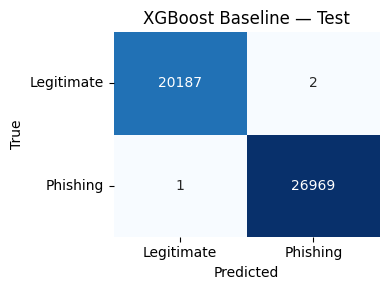

In [5]:
base_preds_train = base_model.predict(X_train_s)
base_probs_train = base_model.predict_proba(X_train_s)[:, 1]
base_preds_val   = base_model.predict(X_val_s)
base_probs_val   = base_model.predict_proba(X_val_s)[:, 1]
base_preds_test  = base_model.predict(X_test_s)
base_probs_test  = base_model.predict_proba(X_test_s)[:, 1]

print_metrics(y_val_np,  base_preds_val,  'BASELINE — Validation')
print_metrics(y_test_np, base_preds_test, 'BASELINE — Test')
plot_confusion_matrix(y_test_np, base_preds_test, 'XGBoost Baseline — Test')

## 4. SHAP on Stratified Sample

**Sampling strategy:**
SHAP is expensive. We don't need it on all instances — only enough to capture
the SHAP signature of each outcome group (TP, TN, FP, FN).

Logic per split:
- **Error groups (FP, FN):** take ALL available — they're rare and every one counts
- **Correct groups (TP, TN):** cap at a budget — they're abundant, diminishing returns past ~N

Budget caps (tunable):
- Train : errors = all, correct capped at `TRAIN_CORRECT_CAP`
- Val   : errors = all, correct capped at `VAL_CORRECT_CAP`
- Test  : errors = all, correct capped at `TEST_CORRECT_CAP`

SHAP is then computed only on the sampled indices. For the meta-feature
matrix we still need all instances — error groups get their real SHAP,
correct groups outside the sample get SHAP imputed as **class-mean SHAP**
from the sampled correct instances. This is valid because correct predictions
are clustered tightly in SHAP space anyway.

In [6]:
# ── Sampling budgets (adjust these to trade speed vs coverage) ──────────────
TRAIN_CORRECT_CAP = 3000   # cap TP+TN per class on train
VAL_CORRECT_CAP   = 100    # cap TP+TN per class on val
TEST_CORRECT_CAP  = 500    # cap TP+TN per class on test
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)

def stratified_shap_sample(preds, y_true, correct_cap):
    """
    Returns indices to compute SHAP on.
    - FP and FN: all instances (errors are rare — keep every one)
    - TP and TN: uniformly sampled up to correct_cap each
    """
    tp = np.where((preds == 1) & (y_true == 1))[0]
    tn = np.where((preds == 0) & (y_true == 0))[0]
    fp = np.where((preds == 1) & (y_true == 0))[0]  # all
    fn = np.where((preds == 0) & (y_true == 1))[0]  # all

    tp_sample = rng.choice(tp, min(correct_cap, len(tp)), replace=False)
    tn_sample = rng.choice(tn, min(correct_cap, len(tn)), replace=False)

    sampled = np.concatenate([tp_sample, tn_sample, fp, fn])
    sampled = np.sort(sampled)

    print(f'    TP sampled: {len(tp_sample)}/{len(tp)} | '
          f'TN sampled: {len(tn_sample)}/{len(tn)} | '
          f'FP (all): {len(fp)} | FN (all): {len(fn)} | '
          f'Total SHAP calls: {len(sampled)}')
    return sampled, {'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}


def compute_shap_sampled(model, X_full, sample_idx, split_name):
    """
    Compute SHAP only on sample_idx rows of X_full.
    Returns full-size SHAP array (n_full x n_features) where:
      - sampled rows: real SHAP values
      - non-sampled rows: imputed as 0.0 (filled in next step with class mean)
    """
    explainer = shap.TreeExplainer(model, data=X_train_s)
    sv_sample = explainer(X_full[sample_idx], check_additivity=False).values

    # sklearn models (RF, GBM, ET) return shape (n, features, 2) — one slice per class.
    # XGBoost returns (n, features) directly. Normalise to 2D by taking class-1 slice.
    if sv_sample.ndim == 3:
        sv_sample = sv_sample[:, :, 1]

    sv_full = np.zeros((X_full.shape[0], sv_sample.shape[1]), dtype=np.float32)
    sv_full[sample_idx] = sv_sample
    print(f'    [{split_name}] SHAP computed on {len(sample_idx)} instances.')
    return sv_full


def impute_correct_shap(sv_full, sample_idx, group_idx):
    """
    For correct instances NOT in the sample, impute with the mean SHAP
    of their sampled peers (TP mean for unsampled TPs, TN mean for unsampled TNs).
    Error instances (FP, FN) are always in sample_idx so need no imputation.
    """
    sample_set = set(sample_idx)

    # TP imputation
    tp_sampled = np.array([i for i in group_idx['tp'] if i in sample_set])
    tp_missing = np.array([i for i in group_idx['tp'] if i not in sample_set])
    if len(tp_sampled) > 0 and len(tp_missing) > 0:
        sv_full[tp_missing] = sv_full[tp_sampled].mean(axis=0)

    # TN imputation
    tn_sampled = np.array([i for i in group_idx['tn'] if i in sample_set])
    tn_missing = np.array([i for i in group_idx['tn'] if i not in sample_set])
    if len(tn_sampled) > 0 and len(tn_missing) > 0:
        sv_full[tn_missing] = sv_full[tn_sampled].mean(axis=0)

    return sv_full


# ── Compute group predictions for sampling ──────────────────────────────────
# Val and test use base model predictions for group assignment
# Train uses base model training predictions
print('=== Stratified SHAP Sampling ===')

print('\n[Train]')
train_sample_idx, train_groups = stratified_shap_sample(
    base_preds_train, y_train_np, TRAIN_CORRECT_CAP
)
print('\n[Val]')
val_sample_idx, val_groups = stratified_shap_sample(
    base_preds_val, y_val_np, VAL_CORRECT_CAP
)
print('\n[Test]')
test_sample_idx, test_groups = stratified_shap_sample(
    base_preds_test, y_test_np, TEST_CORRECT_CAP
)

=== Stratified SHAP Sampling ===

[Train]
    TP sampled: 3000/94395 | TN sampled: 3000/70659 | FP (all): 2 | FN (all): 0 | Total SHAP calls: 6002

[Val]
    TP sampled: 100/13482 | TN sampled: 100/10093 | FP (all): 2 | FN (all): 3 | Total SHAP calls: 205

[Test]
    TP sampled: 500/26969 | TN sampled: 500/20187 | FP (all): 2 | FN (all): 1 | Total SHAP calls: 1003


In [7]:
# ── Compute SHAP for all 4 models on sampled indices only ───────────────────
print('Computing SHAP values on stratified samples...')
shap_store = {}
all_models = {'XGBoost': base_model, **ensemble_members}

for name, model in all_models.items():
    print(f'\n  [{name}]')

    sv_train = compute_shap_sampled(model, X_train_s, train_sample_idx, 'train')
    sv_train = impute_correct_shap(sv_train, train_sample_idx, train_groups)

    sv_val = compute_shap_sampled(model, X_val_s, val_sample_idx, 'val')
    sv_val = impute_correct_shap(sv_val, val_sample_idx, val_groups)

    sv_test = compute_shap_sampled(model, X_test_s, test_sample_idx, 'test')
    sv_test = impute_correct_shap(sv_test, test_sample_idx, test_groups)

    shap_store[name] = {'train': sv_train, 'val': sv_val, 'test': sv_test}

print('\nAll SHAP values computed and imputed.')

Computing SHAP values on stratified samples...

  [XGBoost]


 98%|===================| 5896/6002 [00:48<00:00]        

    [train] SHAP computed on 6002 instances.
    [val] SHAP computed on 205 instances.
    [test] SHAP computed on 1003 instances.

  [HistGradientBoosting]


 99%|===================| 5955/6002 [01:01<00:00]        

    [train] SHAP computed on 6002 instances.
    [val] SHAP computed on 205 instances.


...

    [train] SHAP computed on 6002 instances.


100%|===================| 408/410 [02:00<00:00]        

    [val] SHAP computed on 205 instances.


100%|===================| 2005/2006 [09:57<00:00]        

    [test] SHAP computed on 1003 instances.

All SHAP values computed and imputed.


## 5. Ensemble Predictions & Disagreement Labels

**Improved error label**: majority vote — XGBoost wrong AND at least 2 of 3
ensemble members predict correctly. Cleaner signal than single-member agreement.

**Separate FP and FN labels**: FP errors (false alarms) and FN errors (missed
phishing) have different SHAP signatures. Training one meta-classifier per
error type gives sharper, more targeted predictions.

In [8]:
def get_all_preds_probs(X_s):
    """Return predictions and probabilities for all 4 models on a split."""
    return {
        'XGB': {
            'preds': base_model.predict(X_s),
            'probs': base_model.predict_proba(X_s)[:, 1]
        },
        'HGB': {
            'preds': hgb_model.predict(X_s),
            'probs': hgb_model.predict_proba(X_s)[:, 1]
        },
        'RF': {
            'preds': rf_model.predict(X_s),
            'probs': rf_model.predict_proba(X_s)[:, 1]
        },
        'ET': {
            'preds': et_model.predict(X_s),
            'probs': et_model.predict_proba(X_s)[:, 1]
        }
    }


pp_train = get_all_preds_probs(X_train_s)
pp_val   = get_all_preds_probs(X_val_s)
pp_test  = get_all_preds_probs(X_test_s)


def make_error_labels(pp, y_true):
    """
    Majority-vote error labels:
      fp_label = 1 when XGB predicted 1 (wrong) AND ≥2 ensemble members predicted 0 (correct)
      fn_label = 1 when XGB predicted 0 (wrong) AND ≥2 ensemble members predicted 1 (correct)
    """
    xgb_preds = pp['XGB']['preds']

    # How many ensemble members got it right
    ensemble_correct = (
        (pp['HGB']['preds'] == y_true).astype(int) +
        (pp['RF']['preds']  == y_true).astype(int) +
        (pp['ET']['preds']  == y_true).astype(int)
    )
    majority_correct = (ensemble_correct >= 2)   # ≥2 of 3 right

    xgb_wrong = (xgb_preds != y_true)

    # FP: XGB said phishing (1) but true label is legitimate (0)
    fp_label = (xgb_wrong & (xgb_preds == 1) & majority_correct).astype(int)

    # FN: XGB said legitimate (0) but true label is phishing (1)
    fn_label = (xgb_wrong & (xgb_preds == 0) & majority_correct).astype(int)

    return fp_label, fn_label


fp_labels_train, fn_labels_train = make_error_labels(pp_train, y_train_np)
fp_labels_val,   fn_labels_val   = make_error_labels(pp_val,   y_val_np)

print('=== Training Error Label Distribution ===')
print(f'  FP labels (correctable false alarms) : {fp_labels_train.sum():,}')
print(f'  FN labels (correctable missed phish) : {fn_labels_train.sum():,}')
print(f'  Total XGB errors on train            : {(pp_train["XGB"]["preds"] != y_train_np).sum():,}')
print(f'  Covered by majority vote             : {fp_labels_train.sum()+fn_labels_train.sum():,}')

=== Training Error Label Distribution ===
  FP labels (correctable false alarms) : 0
  FN labels (correctable missed phish) : 0
  Total XGB errors on train            : 2
  Covered by majority vote             : 0


## 6. Build Meta-Features

In [9]:
def build_meta_features(pp, shap_sv, split):
    """
    Meta-features per instance:
      - 4 model probabilities
      - 4 disagreement signals (per-member binary + weighted)
      - SHAP(XGB), SHAP(RF), SHAP_delta(XGB - RF)
    """
    xgb_probs = pp['XGB']['probs']
    xgb_preds = pp['XGB']['preds']

    d_HGB = (pp['HGB']['preds'] != xgb_preds).astype(float)
    d_rf  = (pp['RF']['preds']  != xgb_preds).astype(float)
    d_et  = (pp['ET']['preds']  != xgb_preds).astype(float)
    d_weighted = d_HGB * 1.0 + d_rf * 2.0 + d_et * 0.5  # RF weighted double

    sv_xgb   = shap_sv['XGBoost'][split]
    sv_rf    = shap_sv['RandomForest'][split]
    sv_delta = sv_xgb - sv_rf

    prob_block     = np.column_stack([xgb_probs, pp['HGB']['probs'],
                                      pp['RF']['probs'], pp['ET']['probs']])
    disagree_block = np.column_stack([d_HGB, d_rf, d_et, d_weighted])

    return np.hstack([prob_block, disagree_block, sv_xgb, sv_rf, sv_delta])


meta_X_train = build_meta_features(pp_train, shap_store, 'train')
meta_X_val   = build_meta_features(pp_val,   shap_store, 'val')
meta_X_test  = build_meta_features(pp_test,  shap_store, 'test')

meta_scaler    = StandardScaler()
meta_X_train_s = meta_scaler.fit_transform(meta_X_train)
meta_X_val_s   = meta_scaler.transform(meta_X_val)
meta_X_test_s  = meta_scaler.transform(meta_X_test)

print(f'Meta-feature shape: {meta_X_train_s.shape}')

Meta-feature shape: (165056, 146)


## 7. Train Separate FP and FN Meta-Classifiers

**Why separate?**
- FP errors: XGB saw features that look like phishing but aren't — SHAP pattern is "over-triggered"
- FN errors: XGB missed subtle phishing signals — SHAP pattern is "under-triggered"
These are fundamentally different signatures. One classifier tries to learn both
simultaneously, diluting each signal. Two classifiers let each specialise.

In [10]:
def train_meta_clf(labels_train, labels_val, name):
    n_neg = (labels_train == 0).sum()
    n_pos = (labels_train == 1).sum()
    if n_pos == 0:
        print(f'  [{name}] No positive labels — skipping.')
        return None
    spw = n_neg / n_pos
    print(f'  [{name}] {n_pos} positive / {n_neg} negative | scale_pos_weight={spw:.1f}')

    clf = xgb.XGBClassifier(
        max_depth=4, n_estimators=200, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        objective='binary:logistic', eval_metric='logloss',
        random_state=SEED, verbosity=0
    )
    clf.fit(
        meta_X_train_s, labels_train,
        eval_set=[(meta_X_val_s, labels_val)],
        verbose=False
    )
    return clf


print('Training FP meta-classifier (catches false alarms)...')
fp_clf = train_meta_clf(fp_labels_train, fp_labels_val, 'FP')

print('Training FN meta-classifier (catches missed phishing)...')
fn_clf = train_meta_clf(fn_labels_train, fn_labels_val, 'FN')

# Error probabilities on all splits
fp_prob_val  = fp_clf.predict_proba(meta_X_val_s)[:, 1]  if fp_clf else np.zeros(len(y_val_np))
fn_prob_val  = fn_clf.predict_proba(meta_X_val_s)[:, 1]  if fn_clf else np.zeros(len(y_val_np))
fp_prob_test = fp_clf.predict_proba(meta_X_test_s)[:, 1] if fp_clf else np.zeros(len(y_test_np))
fn_prob_test = fn_clf.predict_proba(meta_X_test_s)[:, 1] if fn_clf else np.zeros(len(y_test_np))

print(f'\nMean FP error prob — val: {fp_prob_val.mean():.4f} | test: {fp_prob_test.mean():.4f}')
print(f'Mean FN error prob — val: {fn_prob_val.mean():.4f} | test: {fn_prob_test.mean():.4f}')

Training FP meta-classifier (catches false alarms)...
  [FP] No positive labels — skipping.
Training FN meta-classifier (catches missed phishing)...
  [FN] No positive labels — skipping.

Mean FP error prob — val: 0.0000 | test: 0.0000
Mean FN error prob — val: 0.0000 | test: 0.0000


## 8. Threshold Sweep on Validation Set

Three hyperparameters now:
- `fp_threshold` : confidence to flip a predicted-phishing → legitimate
- `fn_threshold` : confidence to flip a predicted-legitimate → phishing
- `uncertainty_band` : how uncertain must XGBoost be?

FP and FN thresholds are swept independently — asymmetric cost structure
(missing phishing = FN = higher cost than false alarm = FP).

In [11]:
def apply_dual_correction(
    base_preds, base_probs, fp_probs, fn_probs,
    fp_threshold, fn_threshold,
    uncertainty_low, uncertainty_high
):
    """
    Separate FP and FN correction with independent thresholds.
    Uncertainty gate still applies to both — don't override highly confident predictions.
    """
    corrected = base_preds.copy()
    for i in range(len(base_preds)):
        p = base_probs[i]
        in_band = uncertainty_low <= p <= uncertainty_high

        if base_preds[i] == 1 and in_band:
            # Candidate FP: predicted phishing, meta says might be wrong
            if fp_probs[i] >= fp_threshold:
                corrected[i] = 0

        elif base_preds[i] == 0 and in_band:
            # Candidate FN: predicted legitimate, meta says might be wrong
            if fn_probs[i] >= fn_threshold:
                corrected[i] = 1

    return corrected


# ── Sweep ────────────────────────────────────────────────────────────────────
# FN threshold lower than FP (catching missed phishing is higher priority)
fn_thresholds   = np.arange(0.25, 0.75, 0.05)
fp_thresholds   = np.arange(0.30, 0.80, 0.05)
uncertainty_bands = [
    (0.20, 0.80), (0.25, 0.75), (0.30, 0.70),
    (0.35, 0.65), (0.40, 0.60)
]

baseline_f1  = f1_score(y_val_np, base_preds_val)
best_f1      = baseline_f1
best_params  = None
sweep_results = []

for low, high in uncertainty_bands:
    for fn_thr in fn_thresholds:
        for fp_thr in fp_thresholds:
            tmp = apply_dual_correction(
                base_preds_val.copy(), base_probs_val,
                fp_prob_val, fn_prob_val,
                fp_threshold=fp_thr, fn_threshold=fn_thr,
                uncertainty_low=low, uncertainty_high=high
            )
            fl   = (base_preds_val != tmp).sum()
            f1   = f1_score(y_val_np, tmp)
            acc  = accuracy_score(y_val_np, tmp)
            rec  = recall_score(y_val_np, tmp)
            prec = precision_score(y_val_np, tmp)

            sweep_results.append({
                'band': f'{low}-{high}', 'fn_thr': fn_thr, 'fp_thr': fp_thr,
                'flips': fl, 'f1': f1, 'acc': acc, 'recall': rec, 'prec': prec
            })

            if f1 > best_f1:
                best_f1 = f1
                best_params = {
                    'fp_threshold': fp_thr, 'fn_threshold': fn_thr,
                    'uncertainty_low': low, 'uncertainty_high': high
                }

sweep_df = pd.DataFrame(sweep_results).sort_values('f1', ascending=False)

print(f'Baseline val F1 : {baseline_f1:.5f}')
print(f'Best corrected  : {best_f1:.5f}  (delta = {best_f1 - baseline_f1:+.5f})')
print(f'Best params     : {best_params}')
print(f'\nTop 10 configurations:')
print(sweep_df.head(10).to_string(index=False))

if best_params is None:
    print('\nNo improvement found — using default params.')
    best_params = {'fp_threshold': 0.50, 'fn_threshold': 0.40,
                   'uncertainty_low': 0.30, 'uncertainty_high': 0.70}

Baseline val F1 : 0.99981
Best corrected  : 0.99981  (delta = +0.00000)
Best params     : None

Top 10 configurations:
   band  fn_thr  fp_thr  flips       f1      acc   recall     prec
0.2-0.8    0.25    0.30      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.35      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.40      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.45      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.50      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.55      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.60      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.65      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.70      0 0.999815 0.999788 0.999778 0.999852
0.2-0.8    0.25    0.75      0 0.999815 0.999788 0.999778 0.999852

No improvement found — using default params.


## 9. Apply to Validation Set

  [Val] No flips made.

============ Dual Meta-Classifier — Validation ============
  Metric         Baseline  Corrected      Delta
  --------------------------------------------
  Accuracy        0.99979    0.99979   +0.00000
  F1              0.99981    0.99981   +0.00000
  Precision       0.99985    0.99985   +0.00000
  Recall          0.99978    0.99978   +0.00000


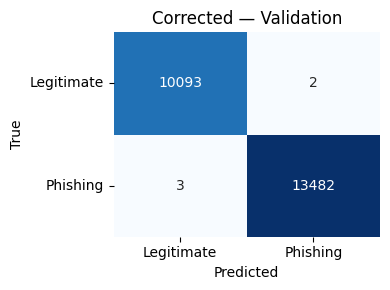

In [12]:
val_preds_corrected = apply_dual_correction(
    base_preds_val.copy(), base_probs_val,
    fp_prob_val, fn_prob_val, **best_params
)
flip_report(base_preds_val, val_preds_corrected, y_val_np, 'Val')
print_comparison(y_val_np, base_preds_val, val_preds_corrected,
                 'Dual Meta-Classifier — Validation')
plot_confusion_matrix(y_val_np, val_preds_corrected, 'Corrected — Validation')

## 10. Final Test Set Evaluation

  [Test] No flips made.

============ Dual Meta-Classifier — Test ============
  Metric         Baseline  Corrected      Delta
  --------------------------------------------
  Accuracy        0.99994    0.99994   +0.00000
  F1              0.99994    0.99994   +0.00000
  Precision       0.99993    0.99993   +0.00000
  Recall          0.99996    0.99996   +0.00000


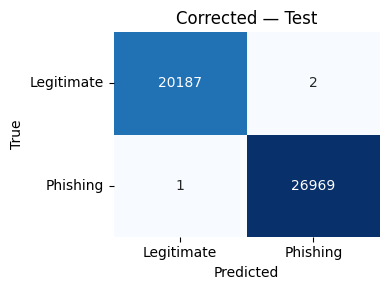

In [13]:
test_preds_corrected = apply_dual_correction(
    base_preds_test.copy(), base_probs_test,
    fp_prob_test, fn_prob_test, **best_params
)
flip_report(base_preds_test, test_preds_corrected, y_test_np, 'Test')
print_comparison(y_test_np, base_preds_test, test_preds_corrected,
                 'Dual Meta-Classifier — Test')
plot_confusion_matrix(y_test_np, test_preds_corrected, 'Corrected — Test')

## 11. Summary Table

In [14]:
print('\n' + '='*72)
print(f"{'Method':<32} {'Acc':>9} {'F1':>9} {'Prec':>9} {'Recall':>9}")
print('='*72)
for label, preds in [
    ('Baseline XGBoost',            base_preds_test),
    ('Dual Meta-Classifier (Ours)', test_preds_corrected)
]:
    print(f"{label:<32} "
          f"{accuracy_score(y_test_np, preds):>9.5f} "
          f"{f1_score(y_test_np, preds):>9.5f} "
          f"{precision_score(y_test_np, preds):>9.5f} "
          f"{recall_score(y_test_np, preds):>9.5f}")
print('='*72)

for metric, fn in [('Accuracy', accuracy_score), ('F1', f1_score),
                   ('Precision', precision_score), ('Recall', recall_score)]:
    d = fn(y_test_np, test_preds_corrected) - fn(y_test_np, base_preds_test)
    print(f"  Delta {metric:<12}: {('+' if d>=0 else '')}{d:.5f}")

print(f'\nBest params: {best_params}')
print(f'\n{classification_report(y_test_np, test_preds_corrected, target_names=["Legitimate", "Phishing"])}')


Method                                 Acc        F1      Prec    Recall
Baseline XGBoost                   0.99994   0.99994   0.99993   0.99996
Dual Meta-Classifier (Ours)        0.99994   0.99994   0.99993   0.99996
  Delta Accuracy    : +0.00000
  Delta F1          : +0.00000
  Delta Precision   : +0.00000
  Delta Recall      : +0.00000

Best params: {'fp_threshold': 0.5, 'fn_threshold': 0.4, 'uncertainty_low': 0.3, 'uncertainty_high': 0.7}

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



## 12. Diagnostic — Flip Analysis

In [15]:
flipped_mask = base_preds_test != test_preds_corrected
n_flipped = flipped_mask.sum()

if n_flipped > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(base_probs_test[~flipped_mask], bins=40, alpha=0.6,
                 label='Not flipped', color='steelblue')
    axes[0].hist(base_probs_test[flipped_mask], bins=20, alpha=0.8,
                 label='Flipped', color='tomato')
    axes[0].set_title('Base Probability — Flipped vs Not')
    axes[0].set_xlabel('XGBoost P(phishing)')
    axes[0].legend()

    axes[1].hist(fn_prob_test[~flipped_mask], bins=40, alpha=0.6,
                 label='Not flipped', color='steelblue')
    axes[1].hist(fn_prob_test[flipped_mask],  bins=20, alpha=0.8,
                 label='Flipped', color='tomato')
    axes[1].set_title('FN Meta-Classifier Probability')
    axes[1].set_xlabel('P(FN error)')
    axes[1].legend()

    axes[2].hist(fp_prob_test[~flipped_mask], bins=40, alpha=0.6,
                 label='Not flipped', color='steelblue')
    axes[2].hist(fp_prob_test[flipped_mask],  bins=20, alpha=0.8,
                 label='Flipped', color='tomato')
    axes[2].set_title('FP Meta-Classifier Probability')
    axes[2].set_xlabel('P(FP error)')
    axes[2].legend()

    plt.suptitle('Flip Diagnostic — Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No flips on test set — consider relaxing uncertainty band or lowering thresholds.')

No flips on test set — consider relaxing uncertainty band or lowering thresholds.
